SAMAGRA GUPTA 590014891 B12 AIML LAB 

EXPERIMENT 1

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error


In [18]:
df = pd.read_csv("Housing.csv")
df.head()


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [19]:
df = pd.get_dummies(df, drop_first=True)
df.head()


,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False


In [20]:
X = df.drop('price', axis=1)
y = df['price']

print(X.shape)
print(y.shape)


(545, 13)
(545,)


In [21]:
y_log = np.log(y)


In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)


In [23]:
model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [24]:
y_pred_log = model.predict(X_test)


In [25]:
y_test_original = np.exp(y_test)
y_pred_original = np.exp(y_pred_log)


In [26]:
mse_original = mean_squared_error(y_test_original, y_pred_original)
mse_log = mean_squared_error(y_test, y_pred_log)

print("MSE (Original Scale):", mse_original)
print("MSE (Log Scale):", mse_log)


MSE (Original Scale): 1728299885729.062
MSE (Log Scale): 0.06329357331376174


In [27]:
B0 = model.intercept_
print("B0 (Intercept in log scale):", B0)


B0 (Intercept in log scale): 14.39248412854912


In [28]:
coefficients = model.coef_

equation = f"log(y) = {B0:.2f}"
for i in range(len(coefficients)):
    equation += f" + ({coefficients[i]:.2f} * {X.columns[i]})"

print("Regression Equation:")
print(equation)


Regression Equation:
log(y) = 14.39 + (0.00 * area) + (0.02 * bedrooms) + (0.19 * bathrooms) + (0.08 * stories) + (0.04 * parking) + (0.11 * mainroad_yes) + (0.05 * guestroom_yes) + (0.10 * basement_yes) + (0.13 * hotwaterheating_yes) + (0.16 * airconditioning_yes) + (0.13 * prefarea_yes) + (0.00 * furnishingstatus_semi-furnished) + (-0.11 * furnishingstatus_unfurnished)


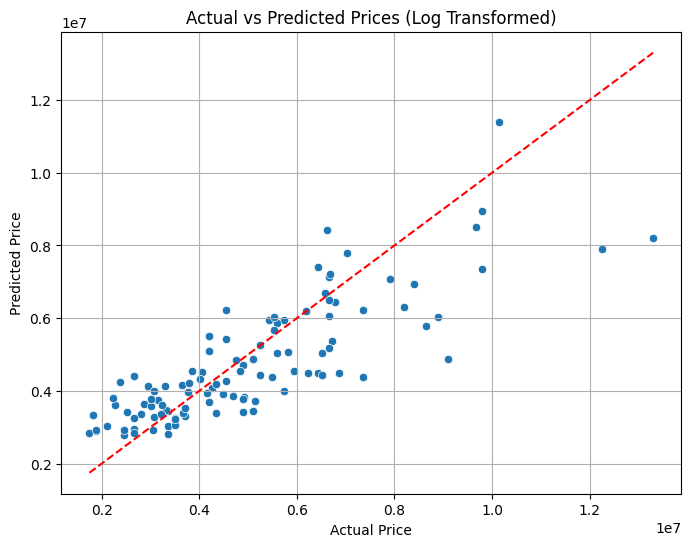

In [29]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test_original, y=y_pred_original)
plt.plot(
    [y_test_original.min(), y_test_original.max()],
    [y_test_original.min(), y_test_original.max()],
    'r--'
)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices (Log Transformed)")
plt.grid(True)
plt.show()
